In [25]:
import datetime
import sys, os, logging
from pathlib import Path

from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
%matplotlib inline 


logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

# Project root
PROJECT_ROOT = Path(os.path.abspath("../../.."))
sys.path.insert(0, str(PROJECT_ROOT))

from inference.prefilter_model.utils import (
    list_h5_parts, load_model, load_mc_test_parts,
    load_exp_parts, load_mc_reco_parts, predict_scores,
    plot_event_3d, load_blind_reco,
    EXP_RECO_COL_NAMES, MC_RECO_COL_NAMES, COMMON_RECO_COLS,
)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
MODEL_NAME = "da_prefilter_numu_260421_2253_Qclip_softlabels_PlateauLR_lambda1.0_MC2M_dmodel128_zflipBothMCExp_BCELoss"
SAVE_DIR = Path(f"./{MODEL_NAME}")

# ── Figures output directory ──
FIGURES_DIR = PROJECT_ROOT / f"experiments/numu/{MODEL_NAME}/figures_test_mcexpreco"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename: str, rewrite=True) -> None:
    """Save figure to FIGURES_DIR; raise FileExistsError if already present."""
    fig_path = FIGURES_DIR / filename
    if not rewrite and fig_path.exists():
        raise FileExistsError(f"Figure already exists: {fig_path}")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")

def get_mask(df, theta_cuts=(0, 30)):
    mask = np.ones(len(df), dtype=bool)
    mask = mask & (df['thetaRec'] > theta_cuts[0]) & (df['thetaRec'] <= theta_cuts[1])
    mask = mask & (df['nHits'] >= 8)
    mask = mask & (df['nStrings'] >= 3)
    mask = mask & (df['covMatrixStatus'] == 3)
    mask = mask & (df['scfMaxTheta'] < 1.7)
    mask = mask & (np.log10(df['pHit']) > -9.)
    mask = mask & (df['evCenterZ'] < 220)
    mask = mask & (df['zDist'] > 70)
    mask = mask & (df['pathLength'] > 50)
    mask = mask & (np.log10(df['funcValue'] / (df['nHits'] - 5)) < 2.)
    mask = mask & (df['nTriplets'] / df['nHits'] > 0.1)
    mask = mask & (df['thetaErr'] < 2.5)
    mask = mask & (df['nCalls'] < 350)
    return mask

In [27]:
JOIN_KEYS  = ["h5_part_str", "local_id"]  # match scalars ↔ arrays

df_exp_scalars = pd.read_parquet(SAVE_DIR / "exp_scalars.parquet")
df_mc_scalars = pd.read_parquet(SAVE_DIR / "mc_scalars.parquet")

FileNotFoundError: [Errno 2] No such file or directory: 'da_prefilter_numu_260421_2253_Qclip_softlabels_PlateauLR_lambda1.0_MC2M_dmodel128_zflipBothMCExp_BCELoss/exp_scalars.parquet'

In [ ]:
df_exp_scalars = df_exp_scalars[(df_exp_scalars['cluster']!=1)]

## Filter events having max Q >1e4 ev
if 'max_q' in df_exp_scalars.columns:
    maxq = df_exp_scalars['max_q']
    df_exp_scalars = df_exp_scalars[maxq <= 1e4].reset_index(drop=True)

In [ ]:
if False:
    print("Loading hit masks for exp...")
    temp_arrays  = feather.read_table(SAVE_DIR / "exp_arrays.arrow", columns=JOIN_KEYS + ['signal_mask', 'reco_hit_prty']).to_pandas()
    nhits_gt = temp_arrays['signal_mask'].apply(sum)
    nhits_reco = temp_arrays['reco_hit_prty'].apply(sum)
    #df_exp = df_exp_scalars.merge(df_exp_arrays, on=JOIN_KEYS)

    print("Loading hit masks for mc...")
    df_mc_arrays  = feather.read_table(SAVE_DIR / "exp_arrays.arrow", columns=JOIN_KEYS + ['signal_mask', 'reco_hit_prty']).to_pandas()
    #df_mc = df_mc_scalars.merge(df_mc_arrays, on=JOIN_KEYS)

    print("Done.")

/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


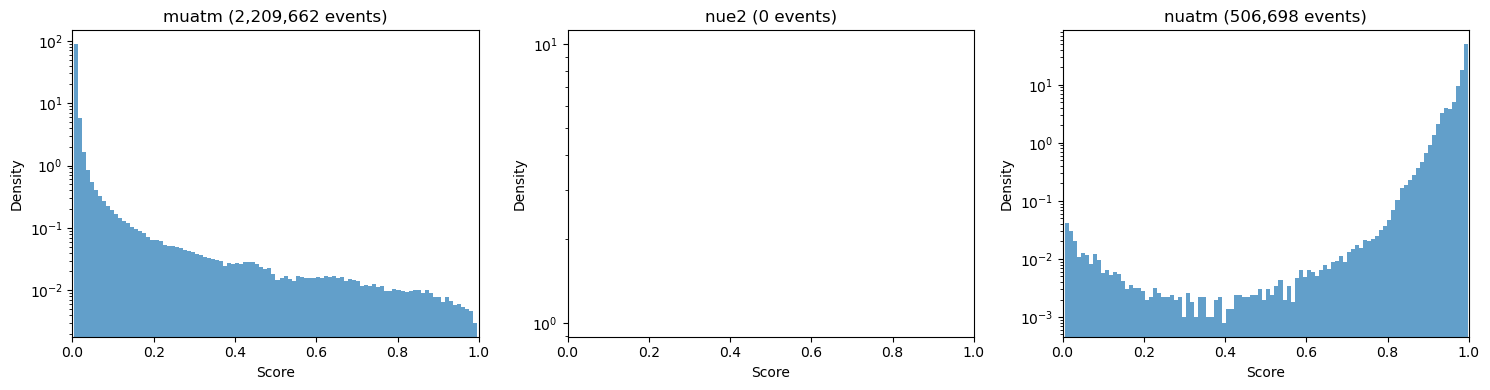

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260410_1119_Qclip_softlabels_PlateauLR_lambda0.3_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_mcexpreco/score_dist_per_particle.png
Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260410_1119_Qclip_softlabels_PlateauLR_lambda0.3_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_mcexpreco/preds_distr_mcexp_reco_cuts_theta(0, 80).png


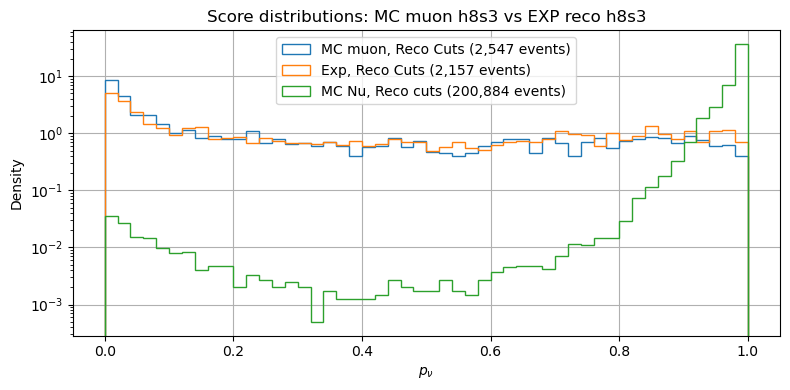

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260410_1119_Qclip_softlabels_PlateauLR_lambda0.3_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_mcexpreco/preds_distr_mcexp_reco_cuts_theta(80, 180).png


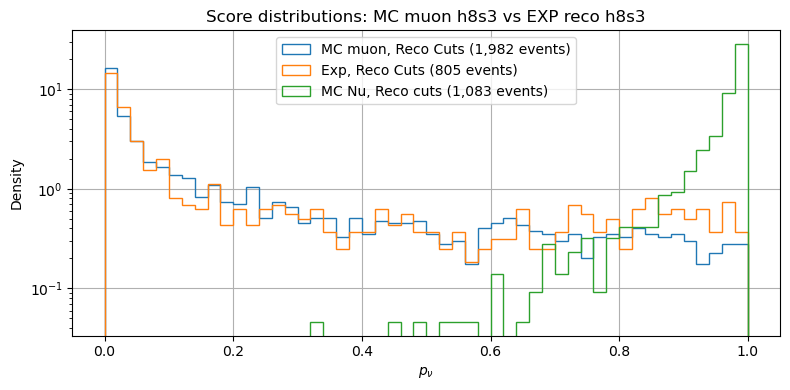

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260410_1119_Qclip_softlabels_PlateauLR_lambda0.3_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_mcexpreco/preds_distr_mcexp_reco_cuts_theta(0, 90).png


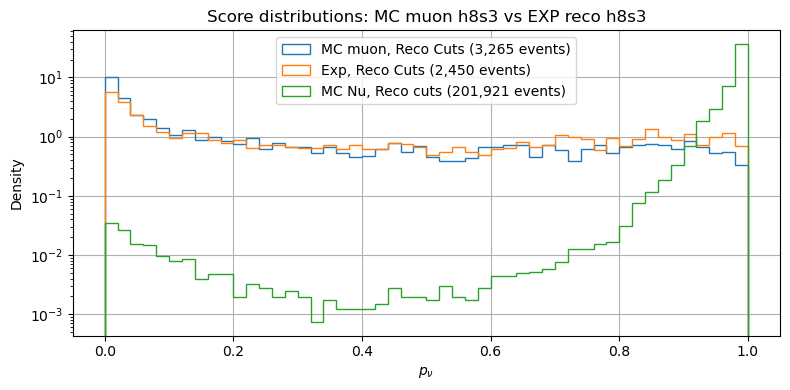

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260410_1119_Qclip_softlabels_PlateauLR_lambda0.3_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_test_mcexpreco/preds_distr_mcexp_reco_cuts_theta(90, 180).png


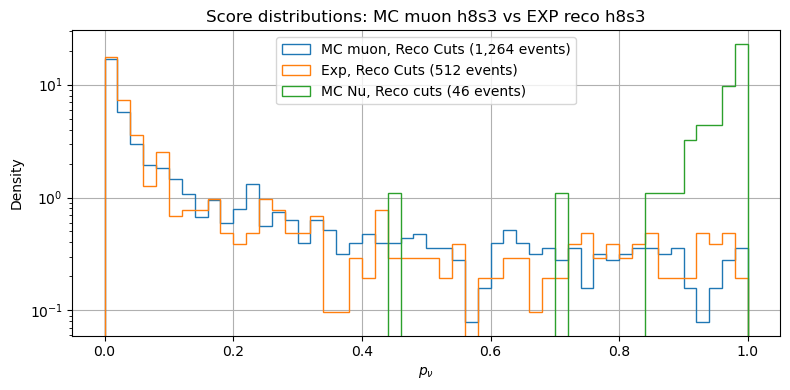

In [ ]:
%matplotlib inline
MASK_BUGS_MC = (df_mc_scalars['n_signal_hits_gt']>5) # Filter Multi Cluster events artifacts


plt.close()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Score distribution per particle type
for ax, ptype in zip(axes, ["muatm", "nue2", "nuatm"]):
    sub = df_mc_scalars[df_mc_scalars["particle_type"].str.startswith(ptype) & MASK_BUGS_MC]
    ax.hist(sub["score"], bins=100, alpha=0.7, log=True, density=True)
    ax.set_title(f"{ptype} ({len(sub):,} events)")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()
save_figure(fig, "score_dist_per_particle.png")

for THETA_CUTS in [(0,80), (80,180), (0,90), (90,180)]:
    mask_exp = get_mask(df_exp_scalars, theta_cuts=THETA_CUTS)
    mask_mc = get_mask(df_mc_scalars, theta_cuts=THETA_CUTS)

    # Score distribution: MC muons vs MC neutrinos vs Exp
    mu = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("muatm")) & mask_mc & MASK_BUGS_MC]["score"]
    nu = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("nu")) & mask_mc & MASK_BUGS_MC]["score"]
    exp_reco = df_exp_scalars["score"][mask_exp]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(mu, bins=50, range=(0,1), histtype='step', log=True, density=True, label=f"MC muon, Reco Cuts ({len(mu):,} events)")
    ax.hist(exp_reco, bins=50, range=(0,1), histtype='step', log=True, density=True, label=f"Exp, Reco Cuts ({len(exp_reco):,} events)")
    ax.hist(nu, bins=50, range=(0,1), histtype='step', log=True, density=True, label=f"MC Nu, Reco cuts ({len(nu):,} events)")
    ax.set_xlabel(r"$p_\nu$")
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_title("Score distributions: MC muon h8s3 vs EXP reco h8s3")
    ax.grid()
    plt.tight_layout()
    save_figure(fig, f"preds_distr_mcexp_reco_cuts_theta{THETA_CUTS}.png")
    plt.show()

THETA_CUTS = (0, 90)

In [ ]:
# df_nu = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("nu")) & mask_mc & MASK_BUGS_MC]
# hist_kwargs = dict(bins=20, histtype='step', density=True)
# df_nu.theta_mc.hist(label='All', **hist_kwargs)
# df_nu[df_nu['score']>0.9].theta_mc.hist(label='Score>0.9', **hist_kwargs)
# df_nu[df_nu['score']<0.1].theta_mc.hist(label='Score<0.1', **hist_kwargs)
# plt.legend()
# plt.xlabel("fTheta")

In [ ]:
# OLD

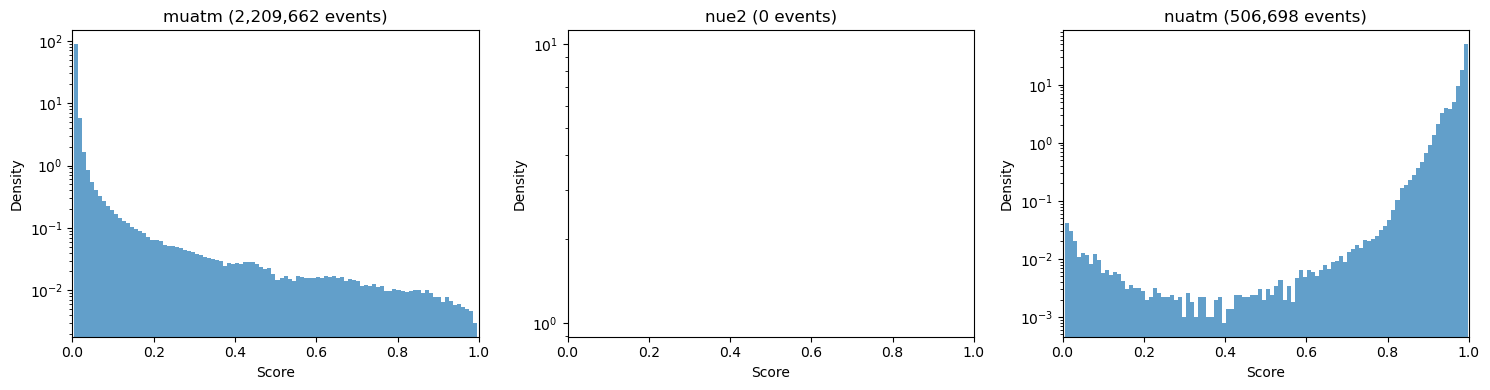

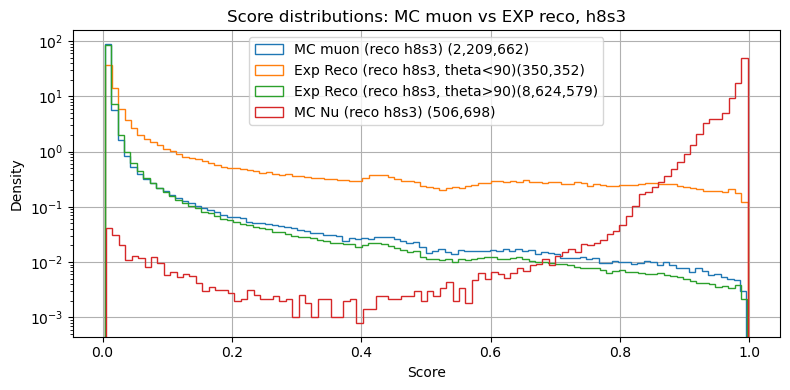

In [ ]:
%matplotlib inline
plt.close()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Score distribution per particle type
for ax, ptype in zip(axes, ["muatm", "nue2", "nuatm"]):
    sub = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith(ptype)) & MASK_BUGS_MC]
    ax.hist(sub["score"], bins=100, alpha=0.7, log=True, density=True)
    ax.set_title(f"{ptype} ({len(sub):,} events)")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# Score distribution: MC muons vs MC neutrinos vs Exp
mask = (df_mc_scalars['nHits']>=8) & (df_mc_scalars['nStrings']>=3)
mu = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("muatm")) & MASK_BUGS_MC]
nu = df_mc_scalars[(df_mc_scalars["particle_type"].str.startswith("nu")) & MASK_BUGS_MC]

mask = (df_exp_scalars['nHits']>=8) & (df_exp_scalars['nStrings']>=3) # Filter Multi Cluster events artifacts
exp_reco_df0 = df_exp_scalars[mask]


for theta_cut in [90]:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(mu["score"], bins=100, histtype='step', log=True, density=True, label=f"MC muon (reco h8s3) ({len(mu):,})")
    #ax.hist(df_exp["score"], bins=100, alpha=0.5, log=True, density=True, label=f"Exp ({len(df_exp):,})")
    exp_reco_up_score = exp_reco_df0["score"][exp_reco_df0['thetaRec'] < theta_cut]
    exp_reco_down_score = exp_reco_df0["score"][exp_reco_df0['thetaRec'] >= theta_cut]
    ax.hist(exp_reco_up_score, bins=100, histtype='step', log=True, density=True, label=f"Exp Reco (reco h8s3, theta<{theta_cut})({sum(~pd.isna(exp_reco_up_score)):,})")
    ax.hist(exp_reco_down_score, bins=100, histtype='step', log=True, density=True, label=f"Exp Reco (reco h8s3, theta>{theta_cut})({sum(~pd.isna(exp_reco_down_score)):,})")
    ax.hist(nu["score"], bins=100, histtype='step', log=True, density=True, label=f"MC Nu (reco h8s3) ({len(nu):,})")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_title("Score distributions: MC muon vs EXP reco, h8s3")
    ax.grid()
    plt.tight_layout()
    plt.show()